<a href="https://colab.research.google.com/github/Raka7317/set_project_work/blob/main/set7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


================ STEP 0: SETUP ================
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✔ Device: cuda

================ STEP 1: PATHS & SAFETY CHECK ================
✅ Found: /content/drive/MyDrive/data/train.csv
✅ Found: /content/drive/MyDrive/data/test.csv
✅ Found: /content/drive/MyDrive/data/phiusiil.csv

================ STEP 2: LOAD & CLEAN DATA ================
train.csv → (160000, 2)
labels
1    80000
0    80000
Name: count, dtype: int64
test.csv → (160000, 2)
labels
1    80000
0    80000
Name: count, dtype: int64
phiusiil.csv → (235795, 2)
labels
1    134850
0    100945
Name: count, dtype: int64

================ STEP 3: LABEL DISTRIBUTION ================


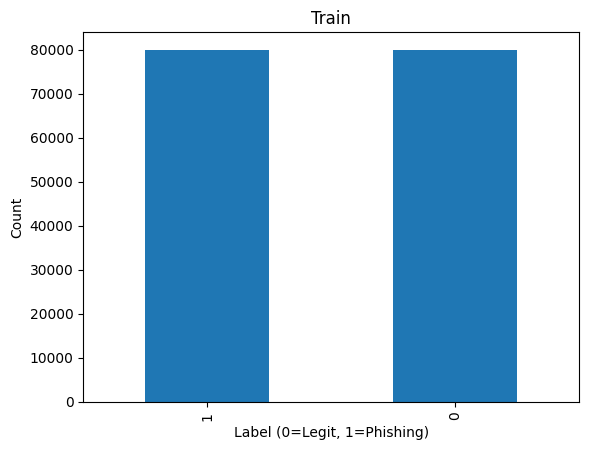

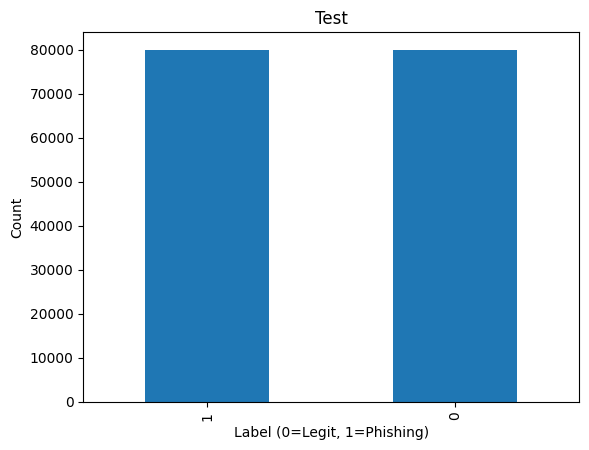

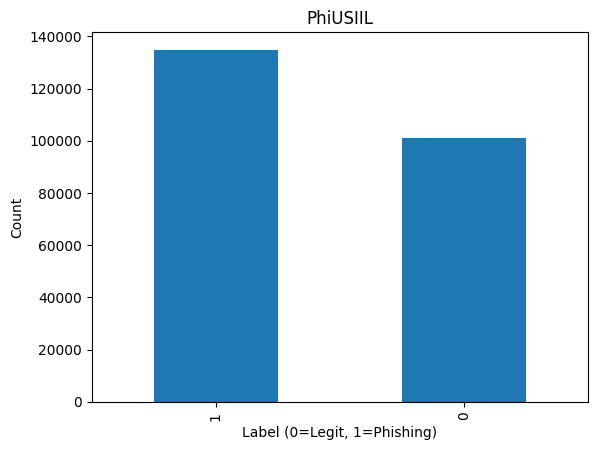


================ STEP 4: LEXICAL FEATURES ================

================ STEP 5: CHAR N-GRAM TF-IDF ================

================ STEP 6: FEATURE FUSION ================

================ STEP 7: SGD CLASSIFIER ================

================ STEP 8: ISOLATION FOREST ================


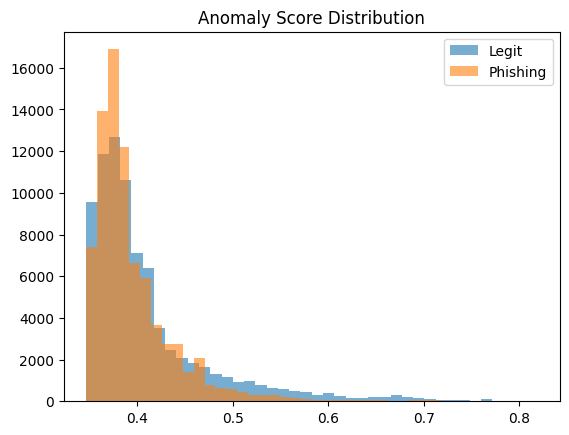


================ STEP 9: TINY TCN + ATTENTION ================
Epoch 1 completed
Epoch 2 completed
Epoch 3 completed

================ STEP 10: HYBRID SCORE FUSION ================

================ STEP 11: EVALUATION + GRAPHS ================

TEST SET
Accuracy : 0.90349375
Precision: 0.8884369622507551
Recall   : 0.922875
F1-score : 0.9053286000698954


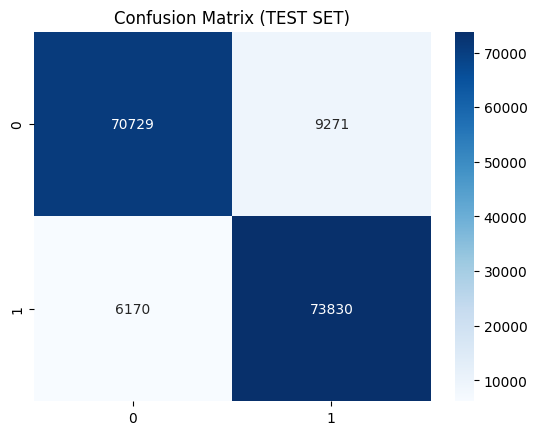

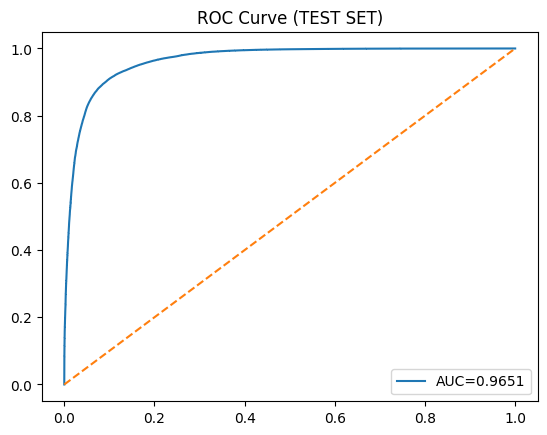

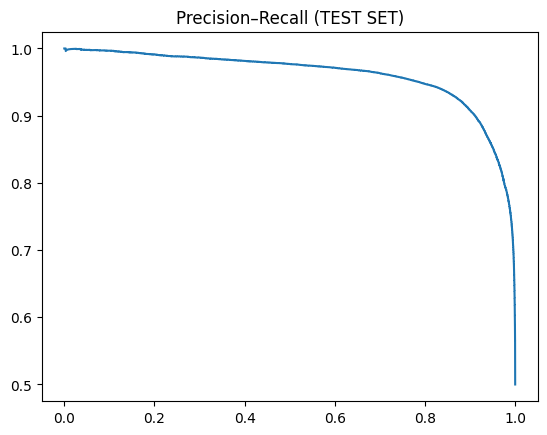


PHIUSIIL DATASET
Accuracy : 0.7782141266778345
Precision: 0.7205651323593848
Recall   : 0.9999851687059695
F1-score : 0.8375860269820368


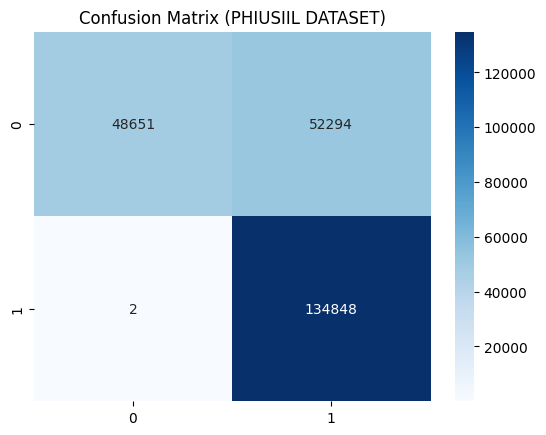

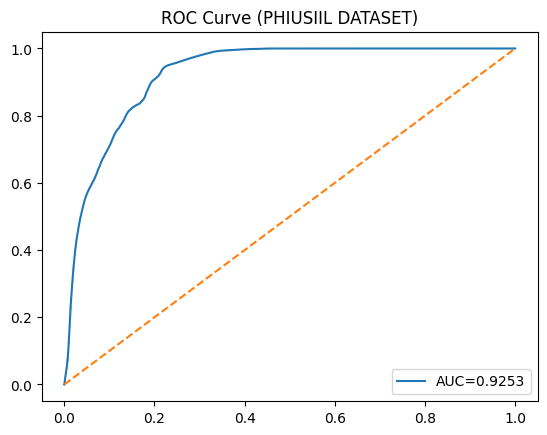

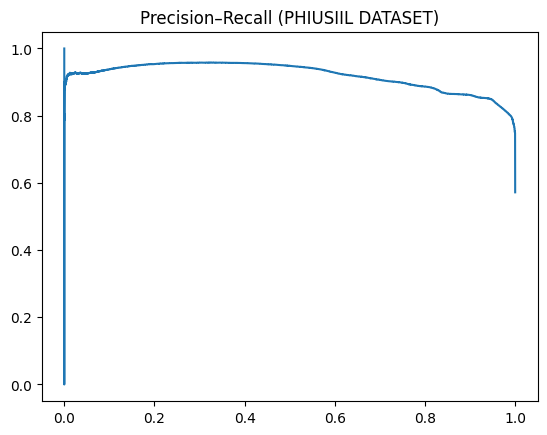


================ STEP 12: ATTENTION MAP ================


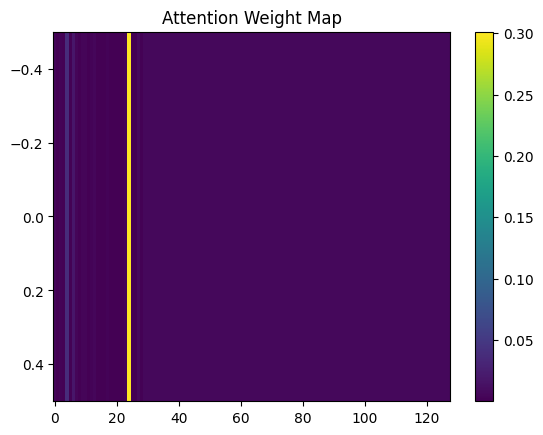


================ STEP 13: CONCEPT DRIFT ================


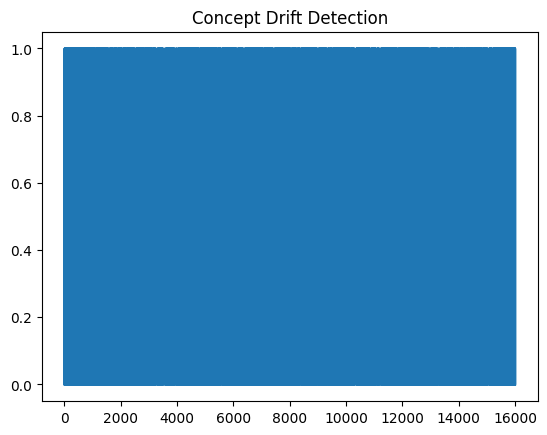


================ PIPELINE COMPLETED SUCCESSFULLY ================


In [3]:
# ==========================================================
# FULL HYBRID PHISHING URL DETECTION SYSTEM
# (MERGED VERSION – ML + DL + ANOMALY + DRIFT + ALL GRAPHS)
# ==========================================================

print("\n================ STEP 0: SETUP ================")

from google.colab import drive
drive.mount("/content/drive")

import os, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc, precision_recall_curve
)
from scipy.sparse import hstack

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✔ Device: {device}")

# ==========================================================
print("\n================ STEP 1: PATHS & SAFETY CHECK ================")

BASE = "/content/drive/MyDrive/data"
TRAIN_PATH = os.path.join(BASE, "train.csv")
TEST_PATH  = os.path.join(BASE, "test.csv")
PHI_PATH   = os.path.join(BASE, "phiusiil.csv")

for p in [TRAIN_PATH, TEST_PATH, PHI_PATH]:
    if not os.path.exists(p):
        raise FileNotFoundError(f"❌ Missing file: {p}")
    print(f"✅ Found: {p}")

# ==========================================================
print("\n================ STEP 2: LOAD & CLEAN DATA ================")

def load_data(path):
    df = pd.read_csv(path)
    if "URL" in df.columns:
        df = df.rename(columns={"URL": "url", "label": "labels"})
    df = df[["url", "labels"]].dropna()
    df["labels"] = df["labels"].astype(int)
    print(f"{os.path.basename(path)} → {df.shape}")
    print(df["labels"].value_counts())
    return df

train_df = load_data(TRAIN_PATH)
test_df  = load_data(TEST_PATH)
phi_df   = load_data(PHI_PATH)

# ==========================================================
print("\n================ STEP 3: LABEL DISTRIBUTION ================")

for name, df in [("Train", train_df), ("Test", test_df), ("PhiUSIIL", phi_df)]:
    df.labels.value_counts().plot(kind="bar", title=name)
    plt.xlabel("Label (0=Legit, 1=Phishing)")
    plt.ylabel("Count")
    plt.show()

# ==========================================================
print("\n================ STEP 4: LEXICAL FEATURES ================")

def lexical_features(url):
    return [
        len(url),
        sum(c.isdigit() for c in url),
        sum(not c.isalnum() for c in url),
        url.count('.'),
        url.count('-'),
        url.count('%'),
        url.count('@'),
        math.log2(len(url) + 1)
    ]

X_lex_train = np.array([lexical_features(u) for u in train_df.url])
X_lex_test  = np.array([lexical_features(u) for u in test_df.url])
X_lex_phi   = np.array([lexical_features(u) for u in phi_df.url])

# ==========================================================
print("\n================ STEP 5: CHAR N-GRAM TF-IDF ================")

tfidf = TfidfVectorizer(analyzer="char", ngram_range=(3, 5), min_df=2)
X_ng_train = tfidf.fit_transform(train_df.url)
X_ng_test  = tfidf.transform(test_df.url)
X_ng_phi   = tfidf.transform(phi_df.url)

# ==========================================================
print("\n================ STEP 6: FEATURE FUSION ================")

X_train = hstack([X_ng_train, X_lex_train]).tocsr()
X_test  = hstack([X_ng_test,  X_lex_test]).tocsr()
X_phi   = hstack([X_ng_phi,   X_lex_phi]).tocsr()

y_train, y_test, y_phi = train_df.labels, test_df.labels, phi_df.labels

# ==========================================================
print("\n================ STEP 7: SGD CLASSIFIER ================")

clf = SGDClassifier(loss="log_loss", random_state=42)
clf.fit(X_train, y_train)

p_ml_test = clf.predict_proba(X_test)[:, 1]
p_ml_phi  = clf.predict_proba(X_phi)[:, 1]

# ==========================================================
print("\n================ STEP 8: ISOLATION FOREST ================")

iso = IsolationForest(contamination=0.1, random_state=42)
iso.fit(X_lex_train[y_train == 0])

a_test = -iso.score_samples(X_lex_test)
a_phi  = -iso.score_samples(X_lex_phi)

plt.hist(a_test[y_test == 0], bins=40, alpha=0.6, label="Legit")
plt.hist(a_test[y_test == 1], bins=40, alpha=0.6, label="Phishing")
plt.legend()
plt.title("Anomaly Score Distribution")
plt.show()

# ==========================================================
print("\n================ STEP 9: TINY TCN + ATTENTION ================")

MAX_LEN = 128
chars = sorted(set("".join(train_df.url.astype(str))))
char2idx = {c: i + 1 for i, c in enumerate(chars)}
char2idx["<PAD>"] = 0

def encode(u):
    s = [char2idx.get(c, 0) for c in str(u)[:MAX_LEN]]
    return s + [0] * (MAX_LEN - len(s))

class URLDataset(Dataset):
    def __init__(self, urls, labels):
        self.X = [encode(u) for u in urls]
        self.y = labels.values
    def __len__(self): return len(self.y)
    def __getitem__(self, i):
        return torch.tensor(self.X[i]), torch.tensor(self.y[i], dtype=torch.float)

train_dl = DataLoader(URLDataset(train_df.url, y_train), 256, shuffle=True)
test_dl  = DataLoader(URLDataset(test_df.url, y_test), 256)
phi_dl   = DataLoader(URLDataset(phi_df.url, y_phi), 256)

class TinyTCNAttn(nn.Module):
    def __init__(self, vocab):
        super().__init__()
        self.emb = nn.Embedding(vocab, 64, padding_idx=0)
        self.conv = nn.Conv1d(64, 64, 3, padding=1)
        self.attn = nn.Linear(64, 1)
        self.fc = nn.Linear(64, 1)
    def forward(self, x, return_attn=False):
        x = self.emb(x).transpose(1, 2)
        x = torch.relu(self.conv(x)).transpose(1, 2)
        w = torch.softmax(self.attn(x).squeeze(-1), 1)
        out = self.fc((x * w.unsqueeze(-1)).sum(1)).squeeze()
        return (out, w) if return_attn else out

model = TinyTCNAttn(len(char2idx)).to(device)
opt = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.BCEWithLogitsLoss()

for e in range(3):
    for X, y in train_dl:
        X, y = X.to(device), y.to(device)
        opt.zero_grad()
        loss = loss_fn(model(X), y)
        loss.backward()
        opt.step()
    print(f"Epoch {e+1} completed")

def dl_scores(dl):
    model.eval()
    scores = []
    with torch.no_grad():
        for X, _ in dl:
            scores.extend(torch.sigmoid(model(X.to(device))).cpu().numpy())
    return np.array(scores)

p_dl_test = dl_scores(test_dl)
p_dl_phi  = dl_scores(phi_dl)

# ==========================================================
print("\n================ STEP 10: HYBRID SCORE FUSION ================")

α = 0.6
S_test = α * p_ml_test + (1 - α) * p_dl_test * (1 - a_test / np.max(a_test))
S_phi  = α * p_ml_phi  + (1 - α) * p_dl_phi  * (1 - a_phi  / np.max(a_phi))

# ==========================================================
print("\n================ STEP 11: EVALUATION + GRAPHS ================")

def evaluate(y, s, name):
    y_pred = (s > 0.5).astype(int)
    print(f"\n{name}")
    print("Accuracy :", accuracy_score(y, y_pred))
    print("Precision:", precision_score(y, y_pred))
    print("Recall   :", recall_score(y, y_pred))
    print("F1-score :", f1_score(y, y_pred))

    cm = confusion_matrix(y, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix ({name})")
    plt.show()

    fpr, tpr, _ = roc_curve(y, s)
    plt.plot(fpr, tpr, label=f"AUC={auc(fpr,tpr):.4f}")
    plt.plot([0,1],[0,1],'--')
    plt.title(f"ROC Curve ({name})")
    plt.legend()
    plt.show()

    p, r, _ = precision_recall_curve(y, s)
    plt.plot(r, p)
    plt.title(f"Precision–Recall ({name})")
    plt.show()

evaluate(y_test, S_test, "TEST SET")
evaluate(y_phi,  S_phi,  "PHIUSIIL DATASET")

# ==========================================================
print("\n================ STEP 12: ATTENTION MAP ================")

sample, _ = next(iter(test_dl))
sample = sample[:1].to(device)
_, attn = model(sample, return_attn=True)

plt.imshow(attn.detach().cpu().numpy(), aspect="auto", cmap="viridis")
plt.colorbar()
plt.title("Attention Weight Map")
plt.show()

# ==========================================================
print("\n================ STEP 13: CONCEPT DRIFT ================")

class PageHinkley:
    def __init__(self, delta=0.005, lam=50):
        self.delta = delta
        self.lam = lam
        self.reset()
    def reset(self):
        self.mean = 0
        self.sum = 0
        self.min = 0
        self.t = 0
    def update(self, x):
        self.t += 1
        self.mean += (x - self.mean) / self.t
        self.sum += x - self.mean - self.delta
        self.min = min(self.min, self.sum)
        if self.sum - self.min > self.lam:
            self.reset()
            return True
        return False

ph = PageHinkley()
losses, drifts = [], []

yhat_test = (S_test > 0.5).astype(int)

for i in range(0, len(y_test), 10):
    err = int(yhat_test[i] != y_test.iloc[i])
    losses.append(err)
    if ph.update(err):
        drifts.append(i)

plt.plot(losses)
for d in drifts:
    plt.axvline(d, color="red", linestyle="--")
plt.title("Concept Drift Detection")
plt.show()

print("\n================ PIPELINE COMPLETED SUCCESSFULLY ================")